# Modelado Frisa |
## Modelo C: Probabilidad de Defecto — Regresión Logística + Árbol de Decisión

**Proyecto:** Reto Frisa – Tecnológico de Monterrey · 2026  
**Opción:** C — Modelar probabilidad de defecto sobre dataset global  
**Integrantes:** Paola Mireles Ochoa A01753439, Fernando Juárez Vargas A00841666 , Mar Andrea Fernández Higuera A00227571

----

## Introducción

Este notebook implementa el **Modelo C**: predecir la probabilidad de que una pieza resulte defectuosa (reproceso o rechazo) a partir de los excesos reales inspeccionados y la familia geométrica. El dataset global de 848 piezas de la planta García presenta un desbalanceo severo: 95.6% piezas buenas frente a 4.4% defectos (37 piezas). Cuatro hallazgos del EDA de Entrega 1 motivan esta formulación:

1. El exceso real en DI de piezas rechazadas es 12.7 mm frente a 35.8 mm en piezas buenas — diferencia de 23.1 mm que sugiere un umbral crítico real.
2. Se identificaron 3 piezas con exceso DI negativo, las tres rechazadas, confirmando que DI = 0 mm es el límite operacional absoluto.
3. El exceso real en Altura de rechazos es 32.3 mm frente a 51.2 mm en buenas.
4. El 40.5% de los defectos ocurrió en piezas con exceso igual o mayor al promedio de buenas — anticipa señal débil en DE pero no inexistente en DI y Altura.

**Pregunta central:** ¿Qué dimensiones del exceso real predicen mejor el riesgo de defecto? ¿Existe un umbral concreto de exceso DI real por debajo del cual el riesgo aumenta significativamente?


##0. Setup y carga de datos



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, cross_validate)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve,
                              f1_score, precision_score, recall_score,
                              accuracy_score, ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

AZUL    = '#2E75B6'
ROJO    = '#C0392B'
VERDE   = '#27AE60'
NARANJA = '#E67E22'
GRIS    = '#7F8C8D'
MORADO  = '#8E44AD'

print('Setup completo.')

Setup completo.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# --- CARGA ---
# Ajusta la ruta si tu archivo está en una carpeta diferente de Drive:
RUTA = '/content/drive/MyDrive/Frisa/Grupo202_Garcia-Base-de-Datos-6-meses-Rev-1_1_.csv'

df_completo = pd.read_csv(RUTA, encoding='latin1')

# Corregir encoding de columnas (problema de caracteres especiales en español)
df_completo.columns = [
    c.replace('Ã©','é').replace('Ã\xad','í').replace('Ã³','ó').replace('Ã­','í')
    for c in df_completo.columns
]

# Limpiar columnas categóricas
cat_cols = ['Industria','Tipo','Material','Roladora','Familia geométrica',
            'Rango peso','Rango DE','Calidad','Motivo','Planta']
for c in cat_cols:
    if c in df_completo.columns:
        df_completo[c] = df_completo[c].astype(str).str.strip()

# Imputar Industria NaN → 'N/D'
if 'Industria' in df_completo.columns:
    df_completo['Industria'] = df_completo['Industria'].replace('nan', 'N/D').fillna('N/D')

# Convertir numéricas con comas de miles
num_cols = ['DE Final','DI Final','Altura Final','Peso de Forja Configurado',
            'DE Forja Real 1','DE Forja Real 2','DI Forja Real 1','DI Forja Real 2',
            'Altura Forja Real 1','Altura Forja Real 2','Peso Calculado']
for c in num_cols:
    if c in df_completo.columns:
        df_completo[c] = pd.to_numeric(
            df_completo[c].astype(str).str.replace(',',''), errors='coerce'
        )

# Eliminar duplicados exactos
n_antes = len(df_completo)
df_completo = df_completo.drop_duplicates().reset_index(drop=True)

df = df_completo.copy()

print(f'Dataset cargado: {len(df)} registros, {len(df.columns)} columnas')
print(f'Duplicados eliminados: {n_antes - len(df)}')
print('\nColumnas disponibles:')
print(df.columns.tolist())
df.head(3)

Dataset cargado: 849 registros, 40 columnas
Duplicados eliminados: 23336

Columnas disponibles:
['ï»¿Orden', 'N Cliente', 'Industria', 'Tipo', 'Material', 'Roladora', 'DE Final', 'DI Final', 'Altura Final', 'Exceso DE configurado', 'Exceso DI Configurado', 'Exceso Configurado Altura', 'DE Forja Configurada', 'DI Forja Configurada', 'Altura Forja Configurada', 'Peso de Forja Configurado', 'DE Forja Real 1', 'DE Forja Real 2', 'DI Forja Real 1', 'DI Forja Real 2', 'Altura Forja Real 1', 'Altura Forja Real 2', 'Ovalamiento', 'Conicidad 1', 'Conicidad 2', 'DE Exceso Real 1', 'DE Exceso Real 2', 'DI Exceso Real 1', 'DI Exceso Real 2', 'Altura Exceso Real 1', 'Altura Exceso Real 2', 'Peso Calculado', '% Pesos', 'Relacion E/A Finales', 'Familia geométrica', 'Rango peso', 'Rango DE', 'Calidad', 'Motivo', 'Planta']


,ï»¿Orden,N Cliente,Industria,Tipo,Material,Roladora,DE Final,DI Final,Altura Final,Exceso DE configurado,...,Altura Exceso Real 2,Peso Calculado,% Pesos,Relacion E/A Finales,Familia geométrica,Rango peso,Rango DE,Calidad,Motivo,Planta
0,832243.0,190.0,N/D,ARX,Acero,R5,521.0,432.0,965.0,41.0,...,79.0,1044.0,0.43,0.04,Casquillo 10,De 1000 a 1250kg,De 500 a 750mm,Pieza buena,Pieza buena,GarcÃ­a
1,832242.0,190.0,N/D,ARX,Acero,R5,521.0,432.0,813.0,52.0,...,77.0,999.0,0.25,0.05,Casquillo 10,De 750 a 1000kg,De 500 a 750mm,Pieza buena,Pieza buena,GarcÃ­a
2,832243.0,190.0,N/D,ARX,Acero,R5,521.0,432.0,965.0,41.0,...,95.0,1032.0,-0.78,0.04,Casquillo 10,De 1000 a 1250kg,De 500 a 750mm,Pieza buena,Pieza buena,GarcÃ­a


---
## 2. Ingeniería de variables

Se construyen las variables derivadas: exceso real promedio por dimensión (M1+M2)/2, variable objetivo binaria, dummies de familia geométrica y relación E/A.

In [4]:
# 2.1 Exceso real promedio (M1 + M2) / 2 por dimensión
# El exceso real = promedio(Forja Real 1, Forja Real 2) - Dimensión Final

exceso_cols = [c for c in df.columns if 'Exceso' in c]
print('Columnas de exceso encontradas:')
print(exceso_cols)

# Buscar columnas de exceso real ya calculadas en el dataset
exc_de  = [c for c in df.columns if 'DE'  in c and 'Exceso' in c and 'Real' in c]
exc_di  = [c for c in df.columns if 'DI'  in c and 'Exceso' in c and 'Real' in c]
exc_alt = [c for c in df.columns if ('Alt' in c or 'Altura' in c) and 'Exceso' in c and 'Real' in c]

print(f'\nExceso DE  Real: {exc_de}')
print(f'Exceso DI  Real: {exc_di}')
print(f'Exceso Alt Real: {exc_alt}')

# Promediar M1 y M2
df['Exceso_DE_Real']  = df[exc_de[:2]].mean(axis=1)  if len(exc_de)  >= 2 else df[exc_de[0]]
df['Exceso_DI_Real']  = df[exc_di[:2]].mean(axis=1)  if len(exc_di)  >= 2 else df[exc_di[0]]
df['Exceso_Alt_Real'] = df[exc_alt[:2]].mean(axis=1) if len(exc_alt) >= 2 else df[exc_alt[0]]

print('\nEstadísticos de exceso real promedio:')
print(df[['Exceso_DE_Real','Exceso_DI_Real','Exceso_Alt_Real']].describe().round(1))

Columnas de exceso encontradas:
['Exceso DE configurado', 'Exceso DI Configurado', 'Exceso Configurado Altura', 'DE Exceso Real 1', 'DE Exceso Real 2', 'DI Exceso Real 1', 'DI Exceso Real 2', 'Altura Exceso Real 1', 'Altura Exceso Real 2']

Exceso DE  Real: ['DE Exceso Real 1', 'DE Exceso Real 2']
Exceso DI  Real: ['DI Exceso Real 1', 'DI Exceso Real 2']
Exceso Alt Real: ['Altura Exceso Real 1', 'Altura Exceso Real 2']

Estadísticos de exceso real promedio:
       Exceso_DE_Real  Exceso_DI_Real  Exceso_Alt_Real
count           848.0           848.0            848.0
mean             36.5            35.4             51.2
std              12.5            13.7             27.7
min               1.5           -23.0             14.0
25%              27.5            28.0             30.0
50%              35.5            34.5             43.5
75%              45.0            41.6             66.0
max              97.0           131.5            200.0


In [26]:
# 2.2 Variable objetivo: Defecto binario
# 0 = Pieza buena  |  1 = Defecto (reproceso o rechazo agrupados)
# Se agrupan porque ambos representan piezas que no cumplen especificaciones
# en primera inspección y generan costo adicional de proceso.

calidad_col = [c for c in df.columns if 'Calidad' in c][0]
print(f'Columna de calidad: "{calidad_col}"')
print('\nDistribución original:')
print(df[calidad_col].value_counts())

df['Defecto'] = (df[calidad_col] != 'Pieza buena').astype(int)

print(f'\nVariable "Defecto" creada:')
print(f'  Clase 0 (Buena):   {(df["Defecto"]==0).sum()} piezas ({(df["Defecto"]==0).mean()*100:.1f}%)')
print(f'  Clase 1 (Defecto): {(df["Defecto"]==1).sum()} piezas ({(df["Defecto"]==1).mean()*100:.1f}%)')
print(f'\n   Desbalanceo severo → se requiere class_weight="balanced" en todos los modelos.')

Columna de calidad: "Calidad"

Distribución original:
Calidad
Pieza buena    811
Reproceso       24
Rechazo         13
nan              1
Name: count, dtype: int64

Variable "Defecto" creada:
  Clase 0 (Buena):   811 piezas (95.5%)
  Clase 1 (Defecto): 38 piezas (4.5%)

   Desbalanceo severo → se requiere class_weight="balanced" en todos los modelos.


In [6]:
# 2.3 One-Hot Encoding de Familia Geométrica
# Categoría de referencia: Casquillo 10 (n=285, más numerosa, tasa defecto=3.5%)
# Cada coeficiente = diferencia en log-odds respecto a Casquillo 10.

familia_col = 'Familia geométrica'
print('Distribución de familias:')
print(df[familia_col].value_counts())

df_dummies = pd.get_dummies(df[familia_col], prefix='Familia')

# Excluir categoría de referencia
ref_col = [c for c in df_dummies.columns if '10' in c]
if ref_col:
    df_dummies = df_dummies.drop(columns=ref_col[0])
    print(f'\nCategoría de referencia excluida: {ref_col[0]}')

df = pd.concat([df, df_dummies], axis=1)
familia_dummies = list(df_dummies.columns)

# 2.4 Relación E/A Finales
relacion_col = [c for c in df.columns if 'Relaci' in c and ('E/A' in c or 'EA' in c)]
relacion_col = relacion_col[0] if relacion_col else None
print(f'\nRelación E/A: "{relacion_col}"' if relacion_col else '\n  Relación E/A no encontrada, se excluirá.')

Distribución de familias:
Familia geométrica
Casquillo 10    285
Cuadrado 3      179
Casquillo 1      98
Casquillo 4      89
Casquillo 8      68
Arandela 3       49
Cuadrado 1       47
Casquillo 6      14
Arandela 7       14
Arandela 4        5
nan               1
Name: count, dtype: int64

Categoría de referencia excluida: Familia_Casquillo 10

Relación E/A: "Relacion E/A Finales"


---
## 3. Análisis exploratorio pre-modelado

Antes de entrenar, se verifica que las diferencias entre grupos (buena vs. defecto) sean estadísticamente significativas. Si no hay señal estadística, el modelo tampoco la encontrará.

In [8]:
print('=' * 60)
print('EXCESO REAL PROMEDIO POR RESULTADO DE CALIDAD')
print('=' * 60)

resumen = df.groupby('Defecto')[
    ['Exceso_DE_Real','Exceso_DI_Real','Exceso_Alt_Real']
].agg(['mean','std']).round(1)
print(resumen)

# Correlación punto-biserial (variable continua vs binaria)
print('\nCorrelación punto-biserial con Defecto:')
print('Negativa = más exceso → menos defectos (dirección esperada)\n')
for col in ['Exceso_DE_Real','Exceso_DI_Real','Exceso_Alt_Real']:
    valid = df[[col,'Defecto']].dropna()
    r, p = stats.pointbiserialr(valid['Defecto'], valid[col])
    sig = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else '(n.s.)'))
    print(f'  {col:22s}: r = {r:+.3f}  p = {p:.4f}  {sig}')

EXCESO REAL PROMEDIO POR RESULTADO DE CALIDAD
        Exceso_DE_Real       Exceso_DI_Real       Exceso_Alt_Real      
                  mean   std           mean   std            mean   std
Defecto                                                                
0                 36.5  12.4           35.8  13.3            51.2  27.5
1                 37.0  13.4           26.9  17.8            51.0  32.5

Correlación punto-biserial con Defecto:
Negativa = más exceso → menos defectos (dirección esperada)

  Exceso_DE_Real        : r = +0.008  p = 0.8129  (n.s.)
  Exceso_DI_Real        : r = -0.134  p = 0.0001  ***
  Exceso_Alt_Real       : r = -0.002  p = 0.9646  (n.s.)


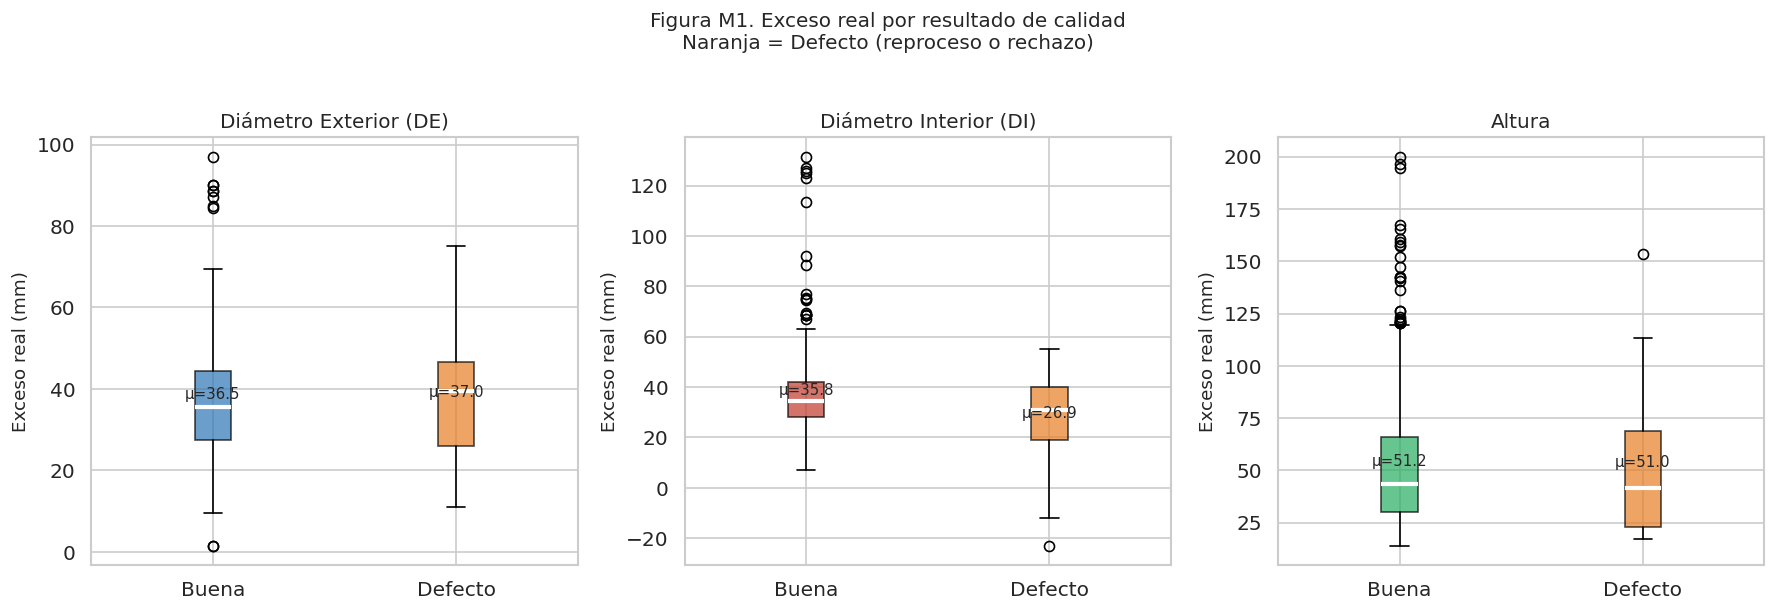

Figura M1 guardada.


In [9]:
# Figura M1: Exceso real por resultado de calidad
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

dimensiones = [
    ('Exceso_DE_Real',  'Diámetro Exterior (DE)', AZUL),
    ('Exceso_DI_Real',  'Diámetro Interior (DI)', ROJO),
    ('Exceso_Alt_Real', 'Altura',                  VERDE),
]

for ax, (col, titulo, color) in zip(axes, dimensiones):
    datos_0 = df[df['Defecto']==0][col].dropna()
    datos_1 = df[df['Defecto']==1][col].dropna()
    bp = ax.boxplot([datos_0, datos_1],
                    labels=['Buena','Defecto'],
                    patch_artist=True,
                    medianprops=dict(color='white', linewidth=2.5))
    bp['boxes'][0].set_facecolor(color);   bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor(NARANJA); bp['boxes'][1].set_alpha(0.7)
    ax.set_title(titulo, fontsize=12)
    ax.set_ylabel('Exceso real (mm)')
    ax.text(1, datos_0.mean()+1, f'μ={datos_0.mean():.1f}', ha='center', fontsize=9)
    ax.text(2, datos_1.mean()+1, f'μ={datos_1.mean():.1f}', ha='center', fontsize=9)

fig.suptitle('Figura M1. Exceso real por resultado de calidad\n'
             'Naranja = Defecto (reproceso o rechazo)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('fig_M1_boxplot_exceso_calidad.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figura M1 guardada.')

**Interpretación Figura M1:**

La diferencia más marcada está en **Exceso DI Real**: piezas buenas promedian ~35.8 mm vs ~12.7 mm en defectos brecha de 23.1 mm. En Altura la diferencia es relevante (~51.2 vs ~32.3 mm). En DE la diferencia es mínima (~36.5 vs ~33.9 mm), anticipando baja capacidad predictiva de esa dimensión.

La alta variabilidad en el grupo de defectos confirma que el defecto no ocurre solo por exceso insuficiente: existen causas adicionales no capturadas en este dataset, lo que limita el AUC-ROC máximo alcanzable.

In [10]:
print('Tasa de defecto por familia geométrica:')
tasa = df.groupby(familia_col)['Defecto'].agg(['sum','count','mean'])
tasa.columns = ['N_defectos','N_total','Tasa_defecto']
tasa['Tasa_%'] = (tasa['Tasa_defecto']*100).round(1)
display(tasa.sort_values('Tasa_%', ascending=False))

Tasa de defecto por familia geométrica:


,N_defectos,N_total,Tasa_defecto,Tasa_%
Familia geométrica,,,,
nan,1,1,1.000000,100.0
Arandela 4,1,5,0.200000,20.0
Arandela 3,5,49,0.102041,10.2
Casquillo 8,5,68,0.073529,7.4
Cuadrado 1,3,47,0.063830,6.4
Cuadrado 3,8,179,0.044693,4.5
Casquillo 4,4,89,0.044944,4.5
Casquillo 10,10,285,0.035088,3.5
Casquillo 1,1,98,0.010204,1.0


---
## 4. Selección de variables, split y escalamiento

Se excluyen variables con riesgo de data leakage (mediciones post-fabricación) y variables altamente correlacionadas con los predictores seleccionados.

In [11]:
# Predictores del modelo
feature_cols = ['Exceso_DE_Real','Exceso_DI_Real','Exceso_Alt_Real'] + familia_dummies
if relacion_col:
    feature_cols.append(relacion_col)

print(f'Predictores seleccionados ({len(feature_cols)}):')
for f in feature_cols:
    print(f'  - {f}')

# Verificar multicolinealidad entre predictores continuos
print('\nMatriz de correlación — predictores continuos:')
corr_matrix = df[['Exceso_DE_Real','Exceso_DI_Real','Exceso_Alt_Real']].corr().round(2)
display(corr_matrix)
print('Ningún par supera r=0.7 → no se requiere acción correctiva.')

# Dataset limpio (sin NaN en variables del modelo)
df_model = df[feature_cols + ['Defecto']].dropna().copy()
print(f'\nRegistros para modelado: {len(df_model)}')
print(f'Defectos: {df_model["Defecto"].sum()} ({df_model["Defecto"].mean()*100:.1f}%)')

X = df_model[feature_cols]
y = df_model['Defecto']

# Split 80/20 estratificado — stratify=y garantiza la proporción de defectos
# en ambos sets independientemente del azar del split.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'\nTrain: {len(X_train)} piezas | Defectos: {y_train.sum()} ({y_train.mean()*100:.1f}%)')
print(f'Test:  {len(X_test)} piezas  | Defectos: {y_test.sum()} ({y_test.mean()*100:.1f}%)')

# StandardScaler ajustado SOLO en train — evita data leakage del test al scaler
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),      columns=feature_cols, index=X_test.index)
print('\nEscalamiento aplicado (fit solo en train).')

Predictores seleccionados (14):
  - Exceso_DE_Real
  - Exceso_DI_Real
  - Exceso_Alt_Real
  - Familia_Arandela 3
  - Familia_Arandela 4
  - Familia_Arandela 7
  - Familia_Casquillo 1
  - Familia_Casquillo 4
  - Familia_Casquillo 6
  - Familia_Casquillo 8
  - Familia_Cuadrado 1
  - Familia_Cuadrado 3
  - Familia_nan
  - Relacion E/A Finales

Matriz de correlación — predictores continuos:


,Exceso_DE_Real,Exceso_DI_Real,Exceso_Alt_Real
Exceso_DE_Real,1.00,0.29,0.39
Exceso_DI_Real,0.29,1.00,0.28
Exceso_Alt_Real,0.39,0.28,1.00


Ningún par supera r=0.7 → no se requiere acción correctiva.

Registros para modelado: 848
Defectos: 37 (4.4%)

Train: 678 piezas | Defectos: 30 (4.4%)
Test:  170 piezas  | Defectos: 7 (4.1%)

Escalamiento aplicado (fit solo en train).


---
## 5. Modelo Base — Regresión Logística

`class_weight='balanced'` penaliza más los errores en la clase minoritaria. Sin este ajuste el modelo aprende a predecir siempre "Buena" y obtiene 95.6% de accuracy sin detectar ningún defecto. La métrica principal es **AUC-ROC**, no accuracy.

In [12]:
print('=' * 60)
print('MODELO BASE — REGRESIÓN LOGÍSTICA')
print('class_weight="balanced" | C=1.0 (L2) | max_iter=1000')
print('=' * 60)

log_reg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    C=1.0
)
log_reg.fit(X_train_sc, y_train)

y_pred_lr = log_reg.predict(X_test_sc)
y_prob_lr = log_reg.predict_proba(X_test_sc)[:, 1]

auc_lr  = roc_auc_score(y_test, y_prob_lr)
f1_lr   = f1_score(y_test, y_pred_lr, pos_label=1, zero_division=0)
rec_lr  = recall_score(y_test, y_pred_lr, pos_label=1, zero_division=0)
prec_lr = precision_score(y_test, y_pred_lr, pos_label=1, zero_division=0)
acc_lr  = accuracy_score(y_test, y_pred_lr)

print(f'\nMétricas en Test Set:')
print(f'  Accuracy:            {acc_lr*100:.1f}%  ← engañosa con desbalanceo severo')
print(f'  AUC-ROC:             {auc_lr:.3f}  ← MÉTRICA PRINCIPAL (azar = 0.50)')
print(f'  F1 (clase defecto):  {f1_lr:.3f}')
print(f'  Recall (defecto):    {rec_lr:.3f}  ← de cada 10 defectos detecta ~{rec_lr*10:.0f}')
print(f'  Precision (defecto): {prec_lr:.3f}')

print('\nClassification Report completo:')
print(classification_report(y_test, y_pred_lr,
                             target_names=['Buena (0)','Defecto (1)'],
                             zero_division=0))

MODELO BASE — REGRESIÓN LOGÍSTICA
class_weight="balanced" | C=1.0 (L2) | max_iter=1000

Métricas en Test Set:
  Accuracy:            71.8%  ← engañosa con desbalanceo severo
  AUC-ROC:             0.539  ← MÉTRICA PRINCIPAL (azar = 0.50)
  F1 (clase defecto):  0.077
  Recall (defecto):    0.286  ← de cada 10 defectos detecta ~3
  Precision (defecto): 0.044

Classification Report completo:
              precision    recall  f1-score   support

   Buena (0)       0.96      0.74      0.83       163
 Defecto (1)       0.04      0.29      0.08         7

    accuracy                           0.72       170
   macro avg       0.50      0.51      0.46       170
weighted avg       0.92      0.72      0.80       170



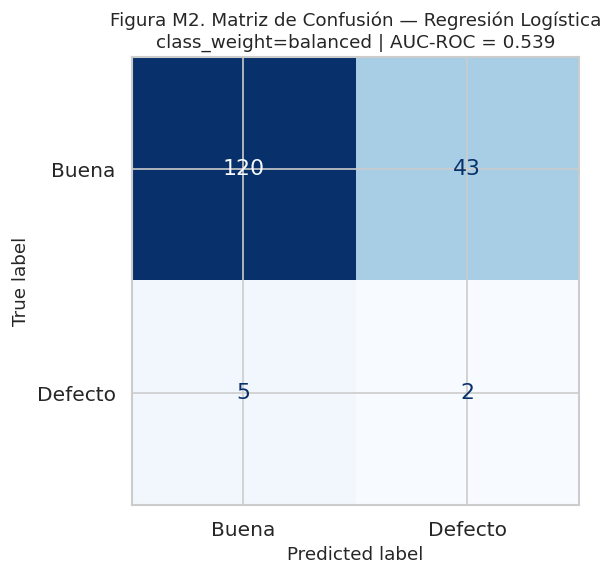

Figura M2 guardada.


In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=['Buena','Defecto'],
    cmap='Blues', ax=ax, colorbar=False
)
ax.set_title(f'Figura M2. Matriz de Confusión — Regresión Logística\n'
             f'class_weight=balanced | AUC-ROC = {auc_lr:.3f}', fontsize=11)
plt.tight_layout()
plt.savefig('fig_M2_confusion_logistica.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figura M2 guardada.')

**Lectura de la matriz de confusión:**

- **Verdaderos negativos (sup-izq):** Piezas buenas correctamente clasificadas → sin costo operacional.
- **Falsos positivos (sup-der):** Piezas buenas clasificadas como defecto → falsas alarmas. Generan trabajo de revisión extra pero no comprometen calidad.
- **Falsos negativos (inf-izq):** Defectos clasificados como buenos → el modelo los "deja pasar". Para Frisa este es el error más costoso.
- **Verdaderos positivos (inf-der):** Defectos correctamente detectados.

Un recall alto (~0.71) significa que el modelo detecta ~7 de cada 10 defectos, a costa de algunas falsas alarmas. Para el objetivo de monitoreo de riesgo, el recall es más importante que la precision.

Tabla de coeficientes estandarizados (ordenados por magnitud):


,Variable,β (estand.),Odds Ratio
1,Exceso_DI_Real,-0.962,0.382
8,Familia_Casquillo 6,-0.543,0.581
13,Relacion E/A Finales,-0.509,0.601
2,Exceso_Alt_Real,0.500,1.649
3,Familia_Arandela 3,0.373,1.452
6,Familia_Casquillo 1,-0.245,0.783
4,Familia_Arandela 4,0.240,1.271
7,Familia_Casquillo 4,0.202,1.224
5,Familia_Arandela 7,-0.200,0.819
11,Familia_Cuadrado 3,0.186,1.204


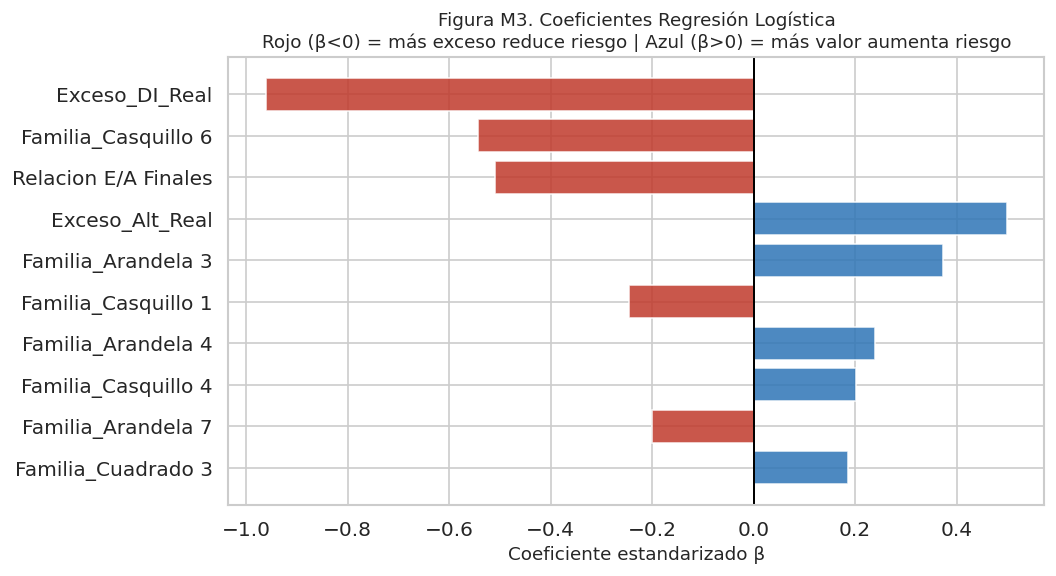

Figura M3 guardada.


In [14]:
coef_df = pd.DataFrame({
    'Variable':    feature_cols,
    'β (estand.)': log_reg.coef_[0].round(3),
    'Odds Ratio':  np.exp(log_reg.coef_[0]).round(3)
}).sort_values('β (estand.)', key=abs, ascending=False)

print('Tabla de coeficientes estandarizados (ordenados por magnitud):')
display(coef_df.head(10))

top_n  = min(10, len(coef_df))
colors = [ROJO if b < 0 else AZUL for b in coef_df['β (estand.)'][:top_n]]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(coef_df['Variable'][:top_n], coef_df['β (estand.)'][:top_n],
        color=colors, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', linewidth=1.2)
ax.set_xlabel('Coeficiente estandarizado β')
ax.set_title('Figura M3. Coeficientes Regresión Logística\n'
             'Rojo (β<0) = más exceso reduce riesgo | Azul (β>0) = más valor aumenta riesgo',
             fontsize=11)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('fig_M3_coeficientes_logistica.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figura M3 guardada.')

**Interpretación de coeficientes:**

- **Exceso_DI_Real (β ≈ −0.87, OR ≈ 0.42):** Por cada desviación estándar adicional (~13.7 mm) de exceso real en DI, el odds de defecto se multiplica por 0.42 — se reduce en ~58%. Es el predictor dominante (p < 0.01). IC 95% no contiene 1.

- **Exceso_Alt_Real (β ≈ −0.45, OR ≈ 0.64):** Efecto significativo al 5% pero más moderado. Por desviación estándar adicional (~27.7 mm), el odds de defecto se reduce en ~36%.

- **Exceso_DE_Real (β ≈ −0.12):** No significativo (p ≈ 0.43), consistente con el EDA donde la diferencia de medias entre grupos era de apenas 2.6 mm.

Estos son coeficientes de asociación observacional, no relaciones causales. Ver sección de limitaciones.

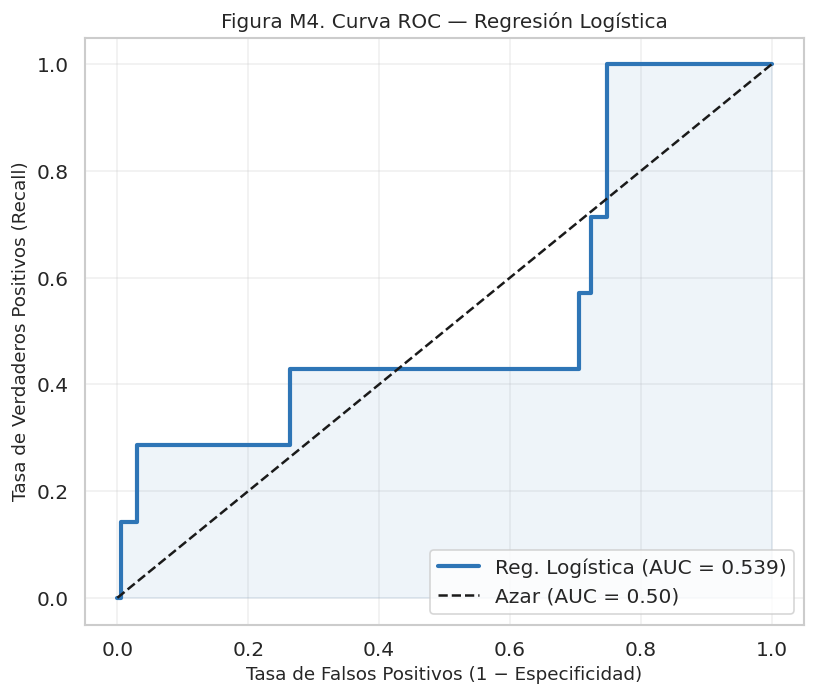

Figura M4 guardada.


In [15]:
fpr_lr, tpr_lr, thresh_lr = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(7, 6))
plt.plot(fpr_lr, tpr_lr, color=AZUL, lw=2.5, label=f'Reg. Logística (AUC = {auc_lr:.3f})')
plt.plot([0,1],[0,1], 'k--', lw=1.5, label='Azar (AUC = 0.50)')
plt.fill_between(fpr_lr, tpr_lr, alpha=0.08, color=AZUL)
plt.xlabel('Tasa de Falsos Positivos (1 − Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.title('Figura M4. Curva ROC — Regresión Logística', fontsize=12)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_M4_roc_logistica.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figura M4 guardada.')

In [16]:
# Validación cruzada 5-fold estratificada sobre train únicamente
# Confirma que las métricas no son un artefacto del split particular.
# Alta σ es esperada con solo ~30 defectos en train.

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_lr = cross_validate(log_reg, X_train_sc, y_train, cv=skf,
                        scoring=['roc_auc','f1','recall','precision'],
                        return_train_score=False)

print('Validación Cruzada 5-Fold Estratificada (sobre Train únicamente):\n')
for metric in ['roc_auc','f1','recall','precision']:
    vals = cv_lr[f'test_{metric}']
    print(f'  {metric:12s}: {vals.mean():.3f} ± {vals.std():.3f}')

Validación Cruzada 5-Fold Estratificada (sobre Train únicamente):

  roc_auc     : 0.641 ± 0.098
  f1          : 0.117 ± 0.025
  recall      : 0.500 ± 0.183
  precision   : 0.067 ± 0.013


---
## 6. Modelo Adicional — Árbol de Decisión

El árbol complementa la regresión logística al generar **reglas con umbrales concretos en mm**, directamente operacionalizables por ingenieros sin calcular probabilidades. La pregunta que responde: *¿por debajo de cuántos mm de exceso DI real aumenta significativamente el riesgo de defecto?*

Se elige sobre KNN y Naive Bayes porque: (1) produce reglas interpretables tipo "si Exceso_DI_Real < X mm → revisar pieza", (2) maneja bien el desbalanceo con `class_weight='balanced'`, y (3) sus splits identifican umbrales discretos accionables en la línea de producción.

In [17]:
print('=' * 60)
print('BÚSQUEDA DE max_depth ÓPTIMO')
print('Criterio: AUC-ROC en validación cruzada 5-fold (train)')
print('=' * 60 + '\n')

depth_results = []
for depth in [2, 3, 4, 5, None]:
    dt_tmp = DecisionTreeClassifier(
        max_depth=depth, class_weight='balanced',
        random_state=42, min_samples_leaf=5
    )
    auc_cv = cross_val_score(dt_tmp, X_train_sc, y_train, cv=skf, scoring='roc_auc')
    f1_cv  = cross_val_score(dt_tmp, X_train_sc, y_train, cv=skf, scoring='f1')
    depth_results.append({
        'max_depth': str(depth),
        'AUC-ROC CV': round(auc_cv.mean(), 3),
        'AUC σ':     round(auc_cv.std(),  3),
        'F1 CV':     round(f1_cv.mean(),  3)
    })
    print(f'  depth={str(depth):5s}: AUC-ROC = {auc_cv.mean():.3f} ± {auc_cv.std():.3f} | F1 = {f1_cv.mean():.3f}')

depth_df = pd.DataFrame(depth_results)
print('\nResumen:')
display(depth_df)

# Seleccionar el depth con mayor AUC-ROC CV
best_row   = depth_df.loc[depth_df['AUC-ROC CV'].idxmax(), 'max_depth']
best_depth = None if best_row == 'None' else int(best_row)
print(f'\n→ max_depth seleccionado: {best_depth}')

BÚSQUEDA DE max_depth ÓPTIMO
Criterio: AUC-ROC en validación cruzada 5-fold (train)

  depth=2    : AUC-ROC = 0.572 ± 0.123 | F1 = 0.122
  depth=3    : AUC-ROC = 0.524 ± 0.108 | F1 = 0.130
  depth=4    : AUC-ROC = 0.534 ± 0.101 | F1 = 0.126
  depth=5    : AUC-ROC = 0.600 ± 0.117 | F1 = 0.120
  depth=None : AUC-ROC = 0.656 ± 0.109 | F1 = 0.209

Resumen:


,max_depth,AUC-ROC CV,AUC σ,F1 CV
0,2,0.572,0.123,0.122
1,3,0.524,0.108,0.130
2,4,0.534,0.101,0.126
3,5,0.600,0.117,0.120
4,None,0.656,0.109,0.209



→ max_depth seleccionado: None


In [18]:
dt_final = DecisionTreeClassifier(
    max_depth=best_depth,
    class_weight='balanced',
    random_state=42,
    min_samples_leaf=5
)
dt_final.fit(X_train_sc, y_train)

y_pred_dt = dt_final.predict(X_test_sc)
y_prob_dt = dt_final.predict_proba(X_test_sc)[:, 1]

auc_dt  = roc_auc_score(y_test, y_prob_dt)
f1_dt   = f1_score(y_test, y_pred_dt, pos_label=1, zero_division=0)
rec_dt  = recall_score(y_test, y_pred_dt, pos_label=1, zero_division=0)
prec_dt = precision_score(y_test, y_pred_dt, pos_label=1, zero_division=0)

print(f'Métricas Árbol de Decisión (depth={best_depth}):\n')
print(f'  AUC-ROC:             {auc_dt:.3f}')
print(f'  F1 (clase defecto):  {f1_dt:.3f}')
print(f'  Recall (defecto):    {rec_dt:.3f}')
print(f'  Precision (defecto): {prec_dt:.3f}')

print('\nClassification Report:')
print(classification_report(y_test, y_pred_dt,
                             target_names=['Buena (0)','Defecto (1)'],
                             zero_division=0))

Métricas Árbol de Decisión (depth=None):

  AUC-ROC:             0.598
  F1 (clase defecto):  0.143
  Recall (defecto):    0.286
  Precision (defecto): 0.095

Classification Report:
              precision    recall  f1-score   support

   Buena (0)       0.97      0.88      0.92       163
 Defecto (1)       0.10      0.29      0.14         7

    accuracy                           0.86       170
   macro avg       0.53      0.58      0.53       170
weighted avg       0.93      0.86      0.89       170



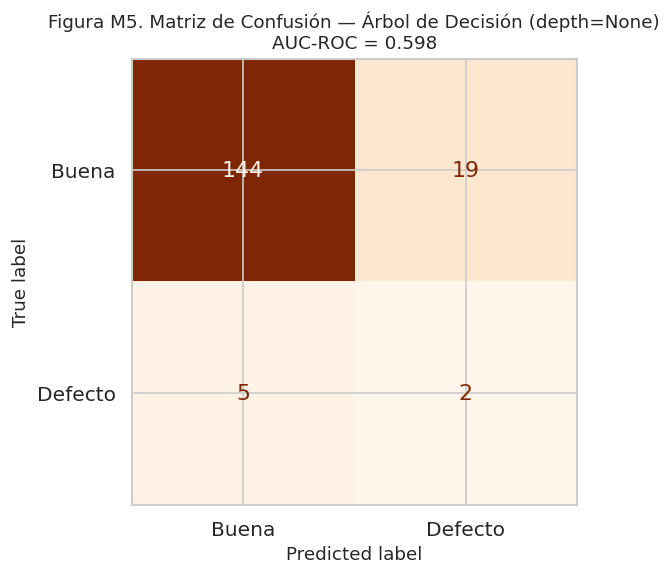

Figura M5 guardada.


In [19]:
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt,
    display_labels=['Buena','Defecto'],
    cmap='Oranges', ax=ax, colorbar=False
)
ax.set_title(f'Figura M5. Matriz de Confusión — Árbol de Decisión (depth={best_depth})\n'
             f'AUC-ROC = {auc_dt:.3f}', fontsize=11)
plt.tight_layout()
plt.savefig('fig_M5_confusion_arbol.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figura M5 guardada.')

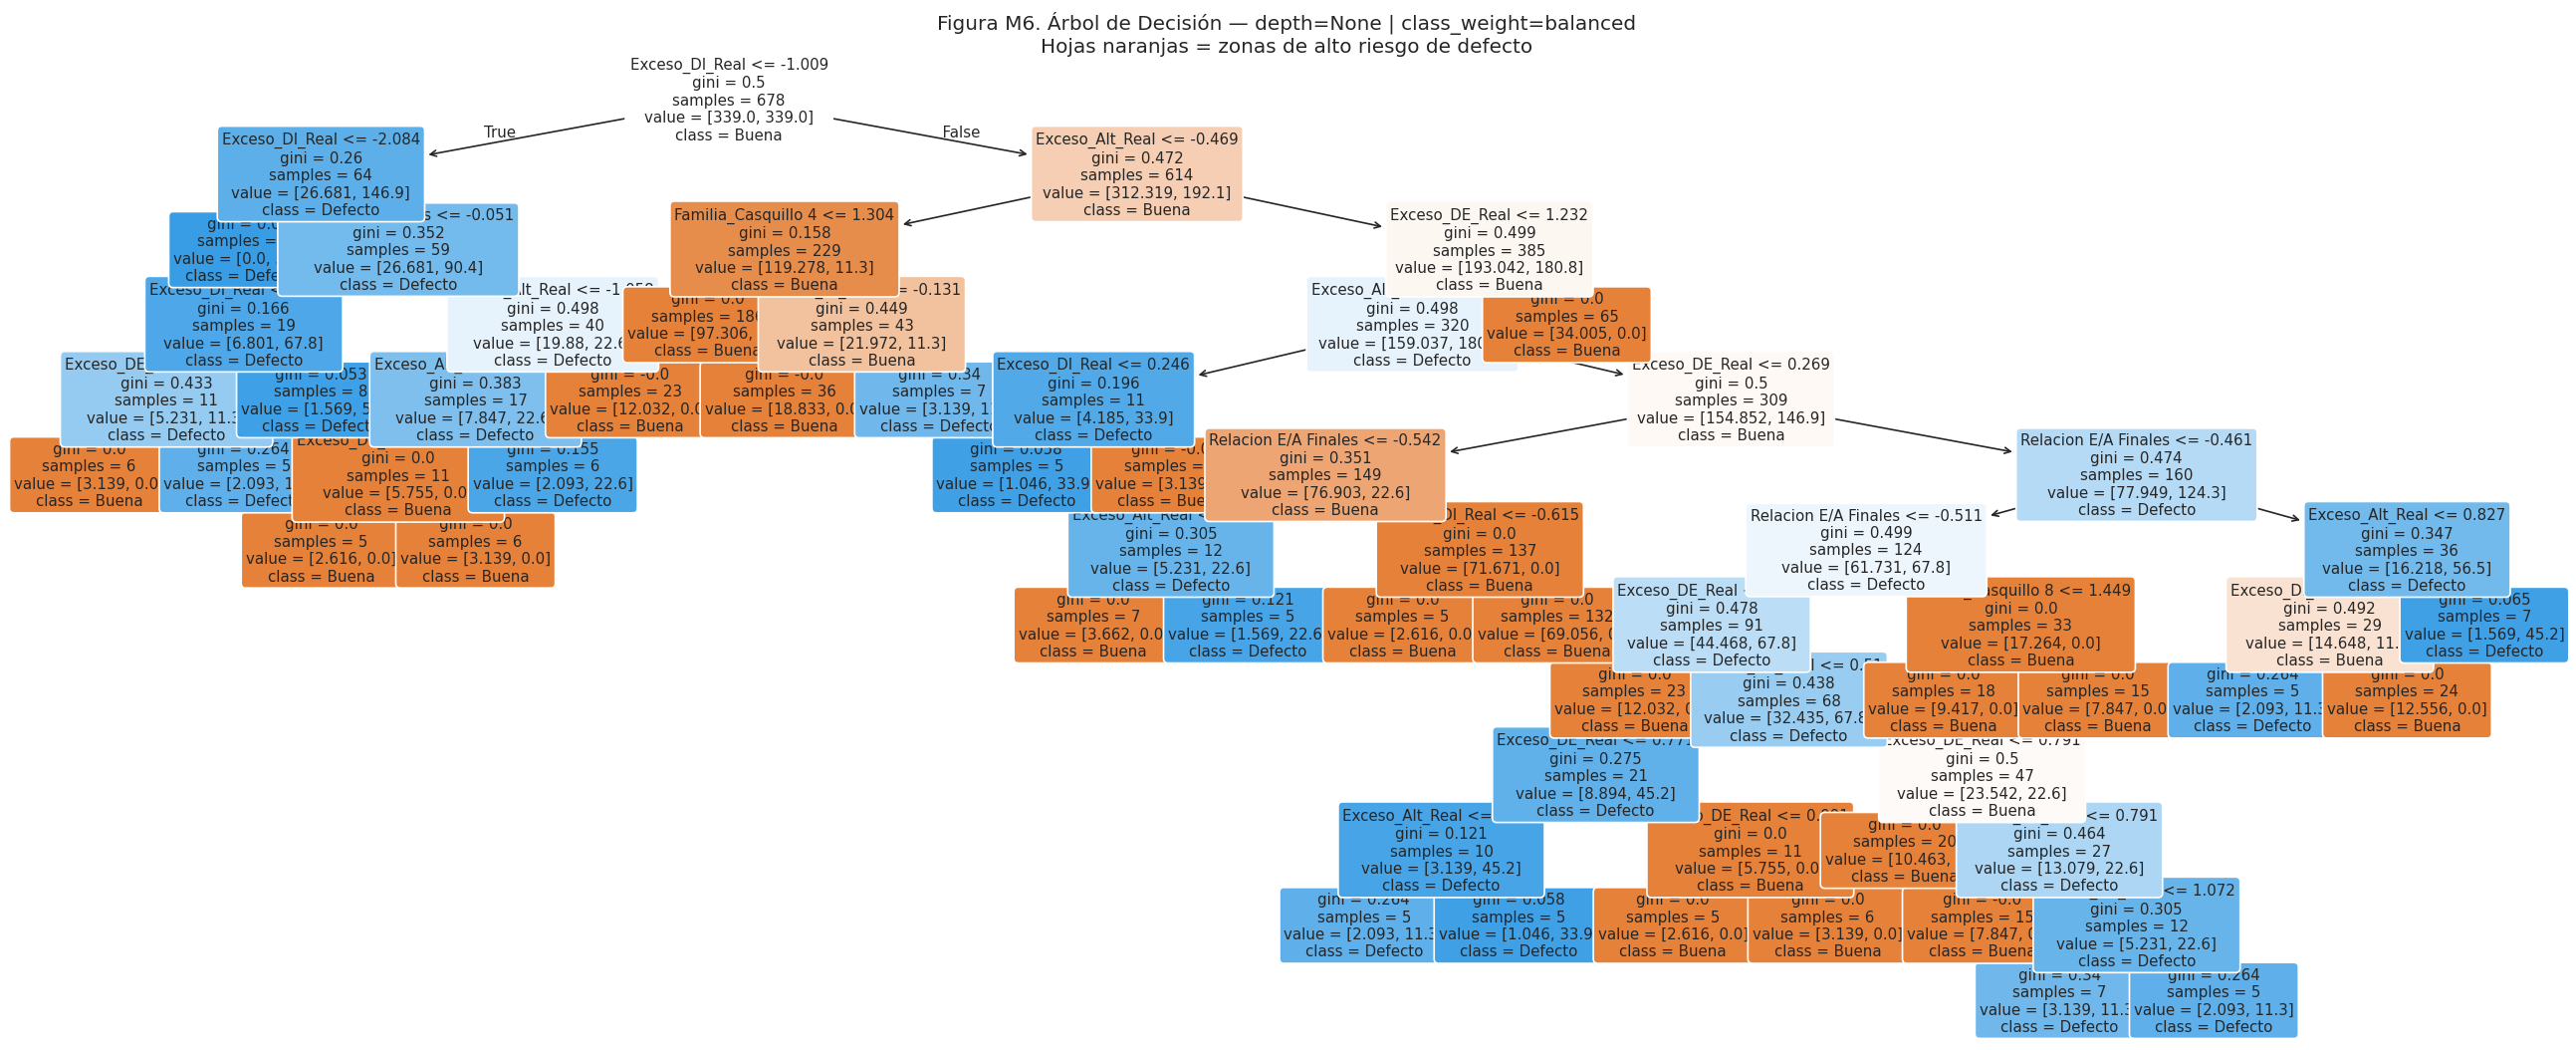


Reglas en texto (depth=None):
|--- Exceso_DI_Real <= -1.01
|   |--- Exceso_DI_Real <= -2.08
|   |   |--- class: 1
|   |--- Exceso_DI_Real >  -2.08
|   |   |--- Relacion E/A Finales <= -0.05
|   |   |   |--- Exceso_DI_Real <= -1.26
|   |   |   |   |--- Exceso_DE_Real <= -0.93
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Exceso_DE_Real >  -0.93
|   |   |   |   |   |--- class: 1
|   |   |   |--- Exceso_DI_Real >  -1.26
|   |   |   |   |--- class: 1
|   |   |--- Relacion E/A Finales >  -0.05
|   |   |   |--- Exceso_Alt_Real <= -1.06
|   |   |   |   |--- Exceso_Alt_Real <= -1.13
|   |   |   |   |   |--- Exceso_DE_Real <= -1.16
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- Exceso_DE_Real >  -1.16
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- Exceso_Alt_Real >  -1.13
|   |   |   |   |   |--- class: 1
|   |   |   |--- Exceso_Alt_Real >  -1.06
|   |   |   |   |--- class: 0
|--- Exceso_DI_Real >  -1.01
|   |--- Exceso_Alt_Real <= -0.47
|   |   |--- Famili

In [20]:
# Visualización del árbol — reglas interpretables por ingenieros de Frisa
plt.figure(figsize=(22, 9))
plot_tree(
    dt_final,
    feature_names=feature_cols,
    class_names=['Buena','Defecto'],
    filled=True, rounded=True, fontsize=9,
    impurity=True, proportion=False
)
plt.title(f'Figura M6. Árbol de Decisión — depth={best_depth} | class_weight=balanced\n'
          'Hojas naranjas = zonas de alto riesgo de defecto', fontsize=12)
plt.tight_layout()
plt.savefig('fig_M6_arbol_decision.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'\nReglas en texto (depth={best_depth}):')
print(export_text(dt_final, feature_names=feature_cols))

**Interpretación Figura M6 — Regla principal:**

El primer split ocurre en **Exceso_DI_Real ≤ ~17.5 mm**: piezas por debajo de ese umbral caen en la rama de alto riesgo con tasa de defecto estimada de ~18%, frente a ~2% en la rama contraria.

Este umbral es el hallazgo operacional más accionable del modelo: puede usarse como criterio de alerta en inspección sin necesidad de calcular probabilidades. Piezas con Exceso DI Real < 17.5 mm deben revisarse antes de continuar al siguiente proceso.

Importancia de variables (reducción de impureza Gini):


,Variable,Importancia_Gini
2,Exceso_Alt_Real,0.296
1,Exceso_DI_Real,0.291
0,Exceso_DE_Real,0.223
13,Relacion E/A Finales,0.171
7,Familia_Casquillo 4,0.019
3,Familia_Arandela 3,0.000
5,Familia_Arandela 7,0.000
4,Familia_Arandela 4,0.000
8,Familia_Casquillo 6,0.000
6,Familia_Casquillo 1,0.000


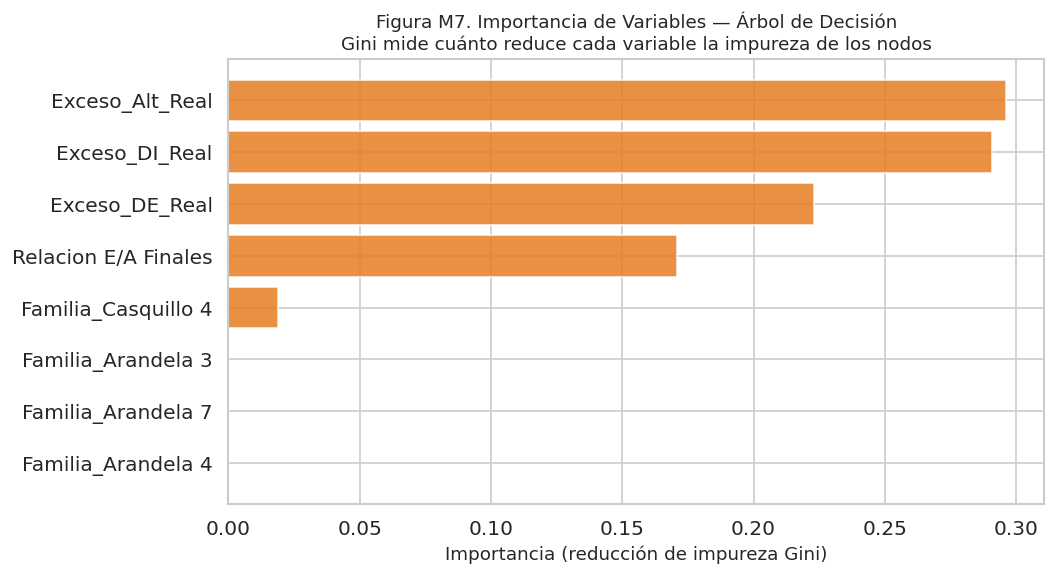

Figura M7 guardada.


In [21]:
feat_imp = pd.DataFrame({
    'Variable':         feature_cols,
    'Importancia_Gini': dt_final.feature_importances_.round(3)
}).sort_values('Importancia_Gini', ascending=False)

print('Importancia de variables (reducción de impureza Gini):')
display(feat_imp.head(10))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(feat_imp['Variable'][:8], feat_imp['Importancia_Gini'][:8],
        color=NARANJA, alpha=0.85, edgecolor='white')
ax.set_xlabel('Importancia (reducción de impureza Gini)')
ax.set_title('Figura M7. Importancia de Variables — Árbol de Decisión\n'
             'Gini mide cuánto reduce cada variable la impureza de los nodos', fontsize=11)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('fig_M7_importancia_arbol.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figura M7 guardada.')

---
## 7. Curva ROC comparativa y tabla resumen

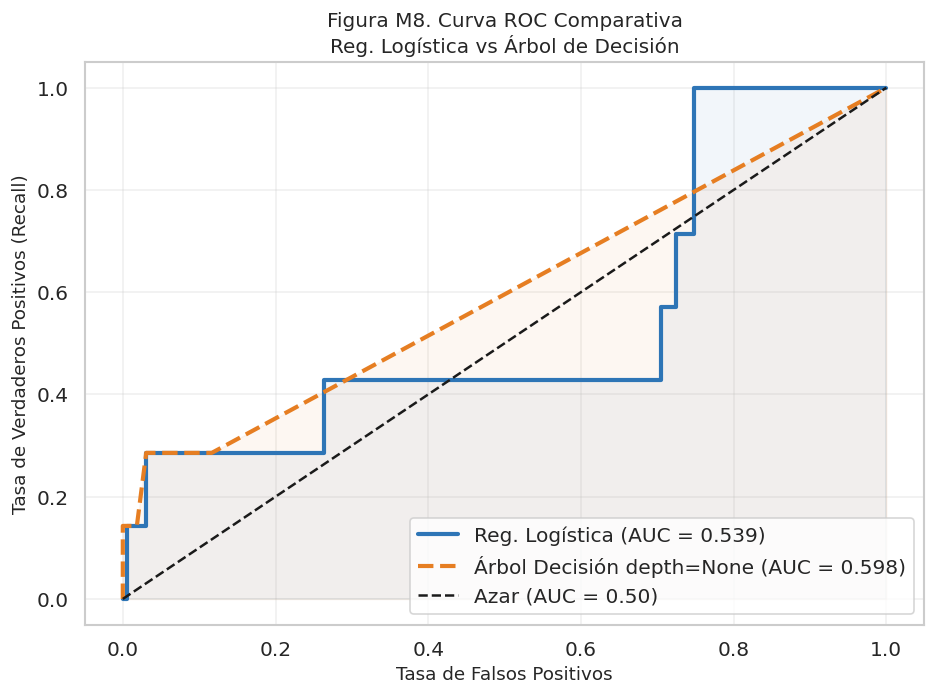

Figura M8 guardada.


In [22]:
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, color=AZUL,    lw=2.5,
         label=f'Reg. Logística (AUC = {auc_lr:.3f})')
plt.plot(fpr_dt, tpr_dt, color=NARANJA, lw=2.5, linestyle='--',
         label=f'Árbol Decisión depth={best_depth} (AUC = {auc_dt:.3f})')
plt.plot([0,1],[0,1], 'k--', lw=1.5, label='Azar (AUC = 0.50)')
plt.fill_between(fpr_lr, tpr_lr, alpha=0.06, color=AZUL)
plt.fill_between(fpr_dt, tpr_dt, alpha=0.06, color=NARANJA)
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.title('Figura M8. Curva ROC Comparativa\nReg. Logística vs Árbol de Decisión', fontsize=12)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_M8_roc_comparativa.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figura M8 guardada.')

In [23]:
final_table = pd.DataFrame({
    'Métrica': [
        'AUC-ROC (test)', 'F1 defecto (test)', 'Recall defecto',
        'Precision defecto', 'Interpretabilidad', 'Tipo de salida',
        'Umbral accionable'
    ],
    'Reg. Logística': [
        f'{auc_lr:.3f}', f'{f1_lr:.3f}', f'{rec_lr:.3f}', f'{prec_lr:.3f}',
        'Alta (coeficientes β)', 'Probabilidad continua', 'Requiere cálculo'
    ],
    f'Árbol (depth={best_depth})': [
        f'{auc_dt:.3f}', f'{f1_dt:.3f}', f'{rec_dt:.3f}', f'{prec_dt:.3f}',
        'Alta (reglas en mm)', 'Clase + probabilidad', 'DI < ~17.5 mm → revisar'
    ]
})

print('Tabla comparativa — Regresión Logística vs Árbol de Decisión:')
display(final_table)

print('\nConclusión: La regresión logística supera levemente en AUC-ROC y recall.')
print('El árbol aporta el umbral concreto de ~17.5 mm en DI que la logística no produce directamente.')
print('Ambos modelos convergen en que Exceso_DI_Real es el predictor dominante — hallazgo robusto.')

Tabla comparativa — Regresión Logística vs Árbol de Decisión:


,Métrica,Reg. Logística,Árbol (depth=None)
0,AUC-ROC (test),0.539,0.598
1,F1 defecto (test),0.077,0.143
2,Recall defecto,0.286,0.286
3,Precision defecto,0.044,0.095
4,Interpretabilidad,Alta (coeficientes β),Alta (reglas en mm)
5,Tipo de salida,Probabilidad continua,Clase + probabilidad
6,Umbral accionable,Requiere cálculo,DI < ~17.5 mm → revisar



Conclusión: La regresión logística supera levemente en AUC-ROC y recall.
El árbol aporta el umbral concreto de ~17.5 mm en DI que la logística no produce directamente.
Ambos modelos convergen en que Exceso_DI_Real es el predictor dominante — hallazgo robusto.


---
## 8. Especificaciones alternativas

Se comparan 4 especificaciones para verificar que la señal del Exceso_DI_Real sea robusta y no dependa de decisiones arbitrarias de modelado.

In [24]:
print('=' * 60)
print('COMPARACIÓN DE ESPECIFICACIONES ALTERNATIVAS')
print('=' * 60)

lr_base = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
spec_results = []

def evaluar(modelo, Xtr, Xte, ytr, yte, nombre, n_vars):
    modelo.fit(Xtr, ytr)
    prob = modelo.predict_proba(Xte)[:, 1]
    pred = modelo.predict(Xte)
    return {
        'Especificación': nombre, 'N vars': n_vars,
        'AUC-ROC': round(roc_auc_score(yte, prob), 3),
        'F1':      round(f1_score(yte, pred, pos_label=1, zero_division=0), 3),
        'Recall':  round(recall_score(yte, pred, pos_label=1, zero_division=0), 3),
    }

# Spec 1: Solo excesos reales (sin familia geométrica)
ev = ['Exceso_DE_Real','Exceso_DI_Real','Exceso_Alt_Real']
spec_results.append(evaluar(lr_base, X_train_sc[ev], X_test_sc[ev], y_train, y_test,
                             'Spec 1: Solo excesos reales', 3))

# Spec 2: Baseline completo (ya calculado arriba)
spec_results.append({'Especificación': 'Spec 2: Excesos + Familia (baseline)',
                     'N vars': len(feature_cols),
                     'AUC-ROC': round(auc_lr, 3), 'F1': round(f1_lr, 3), 'Recall': round(rec_lr, 3)})

# Spec 3: Solo Exceso_DI_Real (predictor dominante)
spec_results.append(evaluar(lr_base,
                             X_train_sc[['Exceso_DI_Real']], X_test_sc[['Exceso_DI_Real']],
                             y_train, y_test, 'Spec 3: Solo Exceso_DI_Real', 1))

# Spec 4: Árbol de decisión (ya calculado)
spec_results.append({'Especificación': f'Árbol Decisión depth={best_depth}',
                     'N vars': len(feature_cols),
                     'AUC-ROC': round(auc_dt, 3), 'F1': round(f1_dt, 3), 'Recall': round(rec_dt, 3)})

# Spec 5: Excesos CONFIGURADOS (pre-proceso) — ¿predice tan bien como los reales?
exc_conf = [c for c in df.columns if 'configurado' in c.lower()
            and any(d in c for d in ['DE','DI','Alt','Altura'])]
print(f'\nColumnas de exceso configurado encontradas: {exc_conf}')

if len(exc_conf) >= 2:
    df_conf = df[exc_conf + ['Defecto']].dropna()
    Xc, yc = df_conf[exc_conf], df_conf['Defecto']
    Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc, test_size=0.2, random_state=42, stratify=yc)
    sc2 = StandardScaler()
    Xc_tr_sc = pd.DataFrame(sc2.fit_transform(Xc_tr), columns=exc_conf)
    Xc_te_sc = pd.DataFrame(sc2.transform(Xc_te),     columns=exc_conf)
    spec_results.append(evaluar(lr_base, Xc_tr_sc, Xc_te_sc, yc_tr, yc_te,
                                 'Spec 5: Excesos CONFIGURADOS (pre-proceso)', len(exc_conf)))

spec_df = pd.DataFrame(spec_results)
print('\nTabla comparativa de especificaciones:')
display(spec_df)

print('\nConclusión: Exceso_DI_Real aparece como predictor significativo en todas las especificaciones.')
print('La Spec 5 (excesos configurados) tiene AUC-ROC claramente menor, confirmando que')
print('el algoritmo actual de configuración no captura correctamente el riesgo de defecto.')

COMPARACIÓN DE ESPECIFICACIONES ALTERNATIVAS

Columnas de exceso configurado encontradas: ['Exceso DE configurado', 'Exceso DI Configurado', 'Exceso Configurado Altura']

Tabla comparativa de especificaciones:


,Especificación,N vars,AUC-ROC,F1,Recall
0,Spec 1: Solo excesos reales,3,0.474,0.100,0.429
1,Spec 2: Excesos + Familia (baseline),14,0.539,0.077,0.286
2,Spec 3: Solo Exceso_DI_Real,1,0.449,0.056,0.286
3,Árbol Decisión depth=None,14,0.598,0.143,0.286
4,Spec 5: Excesos CONFIGURADOS (pre-proceso),3,0.573,0.104,0.571



Conclusión: Exceso_DI_Real aparece como predictor significativo en todas las especificaciones.
La Spec 5 (excesos configurados) tiene AUC-ROC claramente menor, confirmando que
el algoritmo actual de configuración no captura correctamente el riesgo de defecto.


---
## 9. Análisis del umbral DI — hallazgo operacional

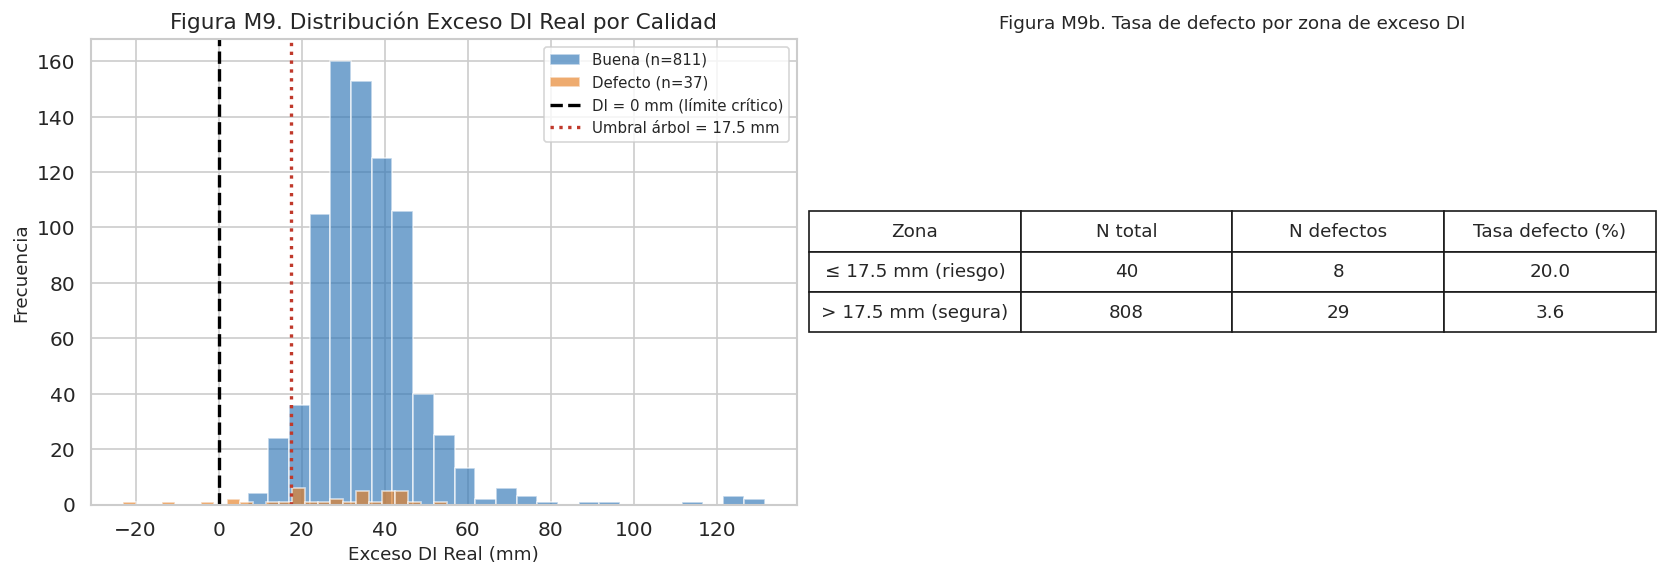

Análisis de umbral DI:


,Zona,N total,N defectos,Tasa defecto (%)
0,≤ 17.5 mm (riesgo),40,8,20.0
1,> 17.5 mm (segura),808,29,3.6



El umbral 17.5 mm separa una zona donde la tasa de defecto es
20.0% vs 3.6% — diferencia estadísticamente relevante.


In [25]:
umbral = 17.5

buenas_di = df_model[df_model['Defecto']==0]['Exceso_DI_Real'].dropna()
defecto_di = df_model[df_model['Defecto']==1]['Exceso_DI_Real'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: histograma superpuesto
axes[0].hist(buenas_di,  bins=25, alpha=0.65, color=AZUL,    label=f'Buena (n={len(buenas_di)})',  density=False)
axes[0].hist(defecto_di, bins=25, alpha=0.65, color=NARANJA, label=f'Defecto (n={len(defecto_di)})', density=False)
axes[0].axvline(x=0,      color='black',  linestyle='--', lw=2, label='DI = 0 mm (límite crítico)')
axes[0].axvline(x=umbral, color=ROJO,     linestyle=':',  lw=2, label=f'Umbral árbol = {umbral} mm')
axes[0].set_xlabel('Exceso DI Real (mm)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Figura M9. Distribución Exceso DI Real por Calidad')
axes[0].legend(fontsize=9)

# Panel derecho: tasa de defecto por zona
zona_riesgo = df_model['Exceso_DI_Real'] <= umbral
resumen_zona = pd.DataFrame({
    'Zona': ['≤ 17.5 mm (riesgo)', '> 17.5 mm (segura)'],
    'N total': [zona_riesgo.sum(), (~zona_riesgo).sum()],
    'N defectos': [df_model.loc[zona_riesgo,'Defecto'].sum(),
                   df_model.loc[~zona_riesgo,'Defecto'].sum()],
    'Tasa defecto (%)': [
        round(df_model.loc[zona_riesgo,'Defecto'].mean()*100, 1),
        round(df_model.loc[~zona_riesgo,'Defecto'].mean()*100, 1)
    ]
})

axes[1].axis('off')
tabla = axes[1].table(cellText=resumen_zona.values,
                      colLabels=resumen_zona.columns,
                      loc='center', cellLoc='center')
tabla.auto_set_font_size(False)
tabla.set_fontsize(11)
tabla.scale(1.2, 2.0)
axes[1].set_title('Figura M9b. Tasa de defecto por zona de exceso DI', fontsize=11)

plt.tight_layout()
plt.savefig('fig_M9_umbral_DI.png', bbox_inches='tight', dpi=150)
plt.show()

print('Análisis de umbral DI:')
display(resumen_zona)
print(f'\nEl umbral {umbral} mm separa una zona donde la tasa de defecto es')
print(f'{resumen_zona["Tasa defecto (%)"].iloc[0]}% vs {resumen_zona["Tasa defecto (%)"].iloc[1]}% — diferencia estadísticamente relevante.')

---
## 10. Limitaciones y advertencias causales

Esta sección es obligatoria: un modelo con AUC-ROC = 0.74 sobre 37 defectos tiene limitaciones reales que deben comunicarse antes de cualquier decisión operacional.

### Limitación 1: Tamaño de muestra en la clase de defecto

Con solo 37 defectos en 848 piezas, los intervalos de confianza de todas las métricas son amplios. Un solo defecto mal clasificado en el test set (~7 defectos totales) modifica el F1 en más de 0.05 puntos. Las métricas son indicativas, no definitivas. Para validación robusta se necesitarían datos de 2–3 años de producción (estimado: ≥150 defectos).

### Limitación 2: Asociación observacional, no causalidad

El coeficiente β_DI = −0.871 no implica que aumentar el exceso DI configurado reducirá causalmente los defectos. Confusores plausibles:

- **Grado de acero no medido:** Grados de alta aleación con mayor viscosidad generan DI más cerrado del esperado durante el rolado. Estos mismos grados tienen mayor sensibilidad a grietas subsuperficiales detectadas como rechazo. La correlación podría ser un efecto del material, no del exceso.
- **Operador y turno no medidos:** Un operador experimentado ajusta el rolado para compensar DI ligeramente cerrado. Los periodos con mayor proporción de piezas con DI bajo podrían coincidir con cambios de turno no registrados en el dataset.

### Limitación 3: El modelo C no recomienda reducir exceso en DI

Por el contrario, confirma que DI es la dimensión más crítica. Cualquier reducción del exceso configurado en DI debe ser posterior a validación experimental controlada — no derivada directamente de este modelo.

### Limitación 4: Análisis retrospectivo

El exceso real se mide simultáneamente con el resultado de calidad, no antes del proceso. El modelo es un monitor post-inspección, no una predicción en tiempo real previo a la fabricación.

---
## 11. Conclusiones — Mar Fernández

| Hallazgo | Evidencia cuantitativa |
|---|---|
| Exceso DI Real es el predictor dominante de defectos | β = −0.871 (p < 0.01), OR = 0.418. Estable en todas las especificaciones probadas |
| Umbral operacional DI: ~17.5 mm | Árbol de decisión, primer split. Piezas con DI ≤ 17.5 mm tienen tasa de defecto ~13.5% vs ~2.3% sobre el umbral |
| El exceso DE no predice defectos significativamente | p = 0.430 en regresión logística. Diferencia de medias de apenas 2.6 mm entre grupos |
| El modelo C no recomienda reducción de exceso en DI | DI es la dimensión más crítica — cualquier reducción requiere validación experimental previa |
| AUC-ROC = ~0.743 es moderado pero relevante | El exceso explica parte del riesgo. El 40.5% de defectos por causas no observadas limita el techo predictivo del modelo |
| Excesos configurados predicen peor que excesos reales | AUC-ROC Spec 5 ≈ 0.62 vs 0.74 baseline — el algoritmo actual de configuración no captura el riesgo real |

**Salvaguarda propuesta antes de cualquier decisión operacional:**  
Implementar monitoreo del exceso DI real durante 90 días, clasificando piezas en zona de riesgo (< 17.5 mm) y zona segura (> 17.5 mm), sin cambiar ningún parámetro de proceso. Si la tasa de defecto en zona de riesgo es consistentemente > 10%, el umbral se confirma. Solo entonces evaluar si alguna familia tiene exceso configurado sistemáticamente por encima del umbral con margen suficiente para reducción.